# Floor bias (over-zero) from the DuckDB warehouse

Runs the deployed floor-bias model against `data/cfb.duckdb` instead of the
`data/raw/lines_*.json` replay log, and reconciles the two sources game by game.

**Why.** The raw JSON files get backfilled in place and their mtimes do not track
their content — refreshing `ROI_HITRATE.md` on 2026-09-22 moved every historical
season's row by a total of +793 graded games with no code change
(`docs/roi-refresh-backfill-2026-09-22.md`). `data/cfb.duckdb` is the repo's
stated source of truth, so it is worth knowing whether it reproduces the result.

**Outcome.** The warehouse is now the model's default source — every
`monitor/` entry point takes `--source` and defaults to `warehouse`. This
notebook is the evidence behind that switch and the way to re-check it. The
write-up is `docs/warehouse-as-model-source-2026-09-22.md`.

Nothing here writes to `docs/`. In particular it never touches
`docs/backtest_bets.csv`, which `roi_report.py` owns.

## 1. Setup

In [1]:
import sys
from pathlib import Path

# models/over_zero is the unit root; v2/ and monitor/ are not packages, so both
# go on sys.path explicitly. `import monitor` would otherwise resolve to the
# directory as a namespace package and fail.
UNIT = Path.cwd()
if UNIT.name == "notebooks":
    UNIT = UNIT.parent
sys.path[:0] = [str(UNIT / "v2"), str(UNIT / "monitor")]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import models_v2
import roi_report
import roi_hitrate_doc
from warehouse_source import load_warehouse_frame, load_warehouse_seasons

SEASONS = list(range(2013, 2027))       # full span, for the raw path
SEASONS_MODEL = list(range(2017, 2027))  # the warehouse's usable span
MIN_TRAIN = 3            # matches the deployed walk-forward
THRESHOLD = 1.75         # the deployed filter
pd.set_option("display.width", 140)

print(f"unit root: {UNIT}")
print(f"warehouse: {models_v2.RAW_DIR.parent / 'cfb.duckdb'}")

unit root: C:\Users\mckel\dev\cfb\models\over_zero
warehouse: C:\Users\mckel\dev\cfb\data\cfb.duckdb


## 2. Load from the warehouse

This section reads `core.fact_game` (`selected_spread` / `selected_total`,
chosen per field) so it can be reconciled game-by-game against the raw JSON.
The **shipped** source is `core.fact_game_line`, compared in section 6.

Both core tables exclude projection sites, so neither carries a usable total
before 2017 — `load_warehouse_seasons` raises rather than letting those seasons
vanish, which is why the frames below are loaded directly.

In [2]:
wh = load_warehouse_frame(SEASONS, lines="fact_game")
wh_data = load_warehouse_seasons(SEASONS_MODEL, lines="fact_game")

print(f"{len(wh):,} gradeable games, {wh.season.nunique()} seasons")
wh.head()

10,300 gradeable games, 10 seasons


,game_id,season,week,start_date,home_team,away_team,spread,total,spread_provider,total_provider,home_points,away_points
0,400938591,2017,1,2017-08-31 18:00:00-04:00,UCF,Florida International,-17.0,56.5,consensus,consensus,61,17
1,400935230,2017,1,2017-08-31 19:00:00-04:00,Minnesota,Buffalo,-23.0,51.0,consensus,consensus,17,7
2,400934493,2017,1,2017-08-31 19:30:00-04:00,Oklahoma State,Tulsa,-19.5,71.5,consensus,consensus,59,24
3,400933828,2017,1,2017-08-31 20:00:00-04:00,Arkansas,Florida A&M,-47.0,55.5,consensus,consensus,49,7
4,400935229,2017,1,2017-08-31 20:00:00-04:00,Indiana,Ohio State,21.0,56.5,consensus,consensus,21,49


In [3]:
(wh.assign(combined=wh.home_points + wh.away_points)
   .groupby("season")
   .agg(games=("game_id", "size"),
        mean_spread=("spread", lambda s: s.abs().mean()),
        mean_total=("total", "mean"),
        mean_combined=("combined", "mean"))
   .round(2))

,games,mean_spread,mean_total,mean_combined
season,,,,
2017,769,11.79,56.17,55.83
2018,785,13.41,56.56,56.96
2019,880,14.03,55.95,55.90
2020,567,12.29,56.88,57.57
2021,887,13.63,55.67,55.19
2022,1454,13.04,54.22,54.86
2023,1404,12.31,52.05,52.90
2024,1552,12.06,52.23,53.28
2025,1593,12.61,52.57,52.82


## 3. Reconcile against the raw JSON

Two questions: which games does each source have that the other does not, and
where the two overlap, do they agree on the line?

In [4]:
def raw_frame(seasons):
    """Same selection rule as models_v2.load_raw_seasons, but keeping game ids."""
    import json
    rows = []
    for season in seasons:
        path = models_v2.RAW_DIR / f"lines_{season}.json"
        if not path.exists():
            continue
        for g in json.loads(path.read_text(encoding="utf-8")):
            hp, ap = g.get("homeScore"), g.get("awayScore")
            if hp is None or ap is None:
                continue
            picked = models_v2.pick_line(g, None)
            if picked is None:
                continue
            spread, total = picked
            if spread == 0:
                continue
            rows.append({"game_id": int(g["id"]), "season": int(season),
                         "spread": float(spread), "total": float(total),
                         "home_points": float(hp), "away_points": float(ap)})
    return pd.DataFrame(rows)


rw = raw_frame(SEASONS)
print(f"raw: {len(rw):,} gradeable games   warehouse: {len(wh):,}")

raw: 13,402 gradeable games   warehouse: 10,300


In [5]:
counts = (pd.concat([
    wh.groupby("season").size().rename("warehouse"),
    rw.groupby("season").size().rename("raw"),
], axis=1).fillna(0).astype(int))
counts["diff"] = counts.warehouse - counts.raw
counts.loc["TOTAL"] = counts.sum()
counts

,warehouse,raw,diff
season,,,
2017,769,784,-15
2018,785,851,-66
2019,880,881,-1
2020,567,567,0
2021,887,887,0
2022,1454,1454,0
2023,1404,1407,-3
2024,1552,1552,0
2025,1593,1594,-1


In [6]:
wh_ids, rw_ids = set(wh.game_id), set(rw.game_id)
only_wh, only_rw = wh_ids - rw_ids, rw_ids - wh_ids
print(f"in warehouse only: {len(only_wh):,}")
print(f"in raw only:       {len(only_rw):,}")
print(f"shared:            {len(wh_ids & rw_ids):,}")

by_season = lambda ids, df: (df[df.game_id.isin(ids)].groupby("season").size()
                             if ids else pd.Series(dtype=int))
pd.concat([by_season(only_wh, wh).rename("warehouse_only"),
           by_season(only_rw, rw).rename("raw_only")], axis=1).fillna(0).astype(int)

in warehouse only: 0
in raw only:       3,102
shared:            10,300


,warehouse_only,raw_only
2013,0,737
2014,0,757
2015,0,762
2016,0,760
2017,0,15
2018,0,66
2019,0,1
2023,0,3
2025,0,1


In [7]:
# Where both sources carry a game, do they pick the same numbers?
both = wh.merge(rw, on=["game_id", "season"], suffixes=("_wh", "_rw"))
both["d_spread"] = both.spread_wh - both.spread_rw
both["d_total"] = both.total_wh - both.total_rw
both["d_score"] = ((both.home_points_wh + both.away_points_wh)
                   - (both.home_points_rw + both.away_points_rw))

print(f"shared games: {len(both):,}")
for col in ("d_spread", "d_total", "d_score"):
    n = int((both[col].abs() > 1e-9).sum())
    print(f"  {col:9} differs on {n:5,} games ({n/len(both):6.2%})"
          + (f"   max |diff| {both[col].abs().max():.2f}" if n else ""))

shared games: 10,300
  d_spread  differs on    47 games ( 0.46%)   max |diff| 7.00
  d_total   differs on     8 games ( 0.08%)   max |diff| 4.50
  d_score   differs on     0 games ( 0.00%)


The spread disagreement is the one worth reading carefully. It is mostly ordinary
book-to-book variation, but the tail is not: a handful of games carry the same
`consensus` label in both sources and still disagree by 20+ points, including
exact sign flips. Those are not two books quoting different numbers — they are
the two sources disagreeing about which side is favoured.

In [8]:
d = both[both.d_spread.abs() > 1e-9]
print("|d_spread| on disagreeing games:")
print(d.d_spread.abs().describe(percentiles=[.5, .75, .9, .99]).round(2).to_string())

flips = int(((both.spread_wh + both.spread_rw).abs() < 1e-9).sum())
print(f"\nexact sign flips (same magnitude, opposite side): {flips}")
print(f"\nwarehouse provider when the spread differs:")
print(d.spread_provider.value_counts().head(5).to_string())

|d_spread| on disagreeing games:
count    47.00
mean      2.06
std       1.41
min       0.50
50%       1.50
75%       2.50
90%       4.00
99%       6.08
max       7.00

exact sign flips (same magnitude, opposite side): 1

warehouse provider when the spread differs:
spread_provider
draftkings                   43
caesars                       2
william hill (new jersey)     1
bovada                        1


In [9]:
worst = d.reindex(d.d_spread.abs().sort_values(ascending=False).index)
worst[["game_id", "season", "home_team", "away_team",
       "spread_wh", "spread_rw", "spread_provider",
       "home_points_wh", "away_points_wh"]].head(10)

,game_id,season,home_team,away_team,spread_wh,spread_rw,spread_provider,home_points_wh,away_points_wh
5629,401524007,2023,Colorado,Colorado State,-17.0,-24.0,draftkings,43,35
6703,401551751,2023,Louisiana,Jacksonville State,-1.5,3.5,draftkings,31,34
6709,401551469,2023,Old Dominion,Western Kentucky,1.0,-4.0,draftkings,35,38
5621,401525503,2023,West Virginia,Pittsburgh,2.0,-2.5,draftkings,17,6
6613,401532629,2023,New Mexico,Utah State,8.5,4.5,draftkings,41,44
6606,401520425,2023,Nebraska,Iowa,1.0,-3.0,draftkings,10,13
5429,401523990,2023,Colorado State,Washington State,8.5,12.5,bovada,24,50
6707,401551752,2023,Boise State,UCLA,2.5,6.5,draftkings,22,35
6614,401520426,2023,Arkansas,Missouri,7.0,10.0,draftkings,14,48
6701,401551733,2023,Ohio,Georgia Southern,-1.5,1.5,draftkings,41,21


In [10]:
disagree = both[both.d_total.abs() > 1e-9]
if len(disagree):
    display(disagree.groupby("season").agg(
        games=("game_id", "size"),
        mean_abs_total_diff=("d_total", lambda s: s.abs().mean().round(3)),
        max_abs_total_diff=("d_total", lambda s: s.abs().max()),
    ))
else:
    print("no total disagreements on shared games")

,games,mean_abs_total_diff,max_abs_total_diff
season,,,
2018,4,2.125,4.5
2023,1,4.500,4.5
2025,3,1.000,1.0


## 4. Walk-forward on the warehouse

Unchanged protocol: for season *t*, fit the Tobit sigmas + probit on seasons
< *t* only, then grade *t*. `warehouse_source` returns the same contract as
`load_raw_seasons`, so `roi_report.walk_forward_bets` runs untouched.

In [11]:
def run(data, label):
    years = sorted(data)
    season, bias, over, prob = roi_report.walk_forward_bets(
        data, years, MIN_TRAIN)[:4]
    sel = bias > THRESHOLD
    n, wins = int(sel.sum()), int(over[sel].sum())
    w = wins / n
    lo, hi = roi_report.wilson_roi(wins, n)
    print(f"{label:10}  N={n:4}  {wins}-{n-wins}  hit={w*100:6.2f}%  "
          f"ROI={roi_report.unit_roi(w)*100:+7.2f}%  95% [{lo*100:+.2f}, {hi*100:+.2f}]")
    return {"season": season, "bias": bias, "over": over, "sel": sel,
            "n": n, "wins": wins, "win": w, "roi": roi_report.unit_roi(w),
            "roi_lo": lo, "roi_hi": hi}


wh_res = run(wh_data, "warehouse 2017+")

warehouse 2017+  N= 209  132-77  hit= 63.16%  ROI= +20.57%  95% [+7.74, +32.50]


### By season

In [12]:
def season_rows(res):
    s_b, o_b, b_b = (res["season"][res["sel"]], res["over"][res["sel"]],
                     res["bias"][res["sel"]])
    yrs = sorted(set(s_b.tolist()))
    return roi_hitrate_doc.rows_for(b_b, o_b, yrs, [str(int(y)) for y in yrs],
                                    lambda t: s_b == t)


def as_frame(rows, keys=("label", "n", "wins", "losses", "win", "roi",
                         "roi_lo", "roi_hi", "clears")):
    df = pd.DataFrame([{k: r.get(k) for k in keys} for r in rows])
    for c in ("win", "roi", "roi_lo", "roi_hi"):
        df[c] = (df[c] * 100).round(2)
    return df


as_frame(season_rows(wh_res))

,label,n,wins,losses,win,roi,roi_lo,roi_hi,clears
0,2020,4,3,1,75.00,43.18,-42.61,82.21,False
1,2021,28,21,7,75.00,43.18,8.14,66.71,True
2,2022,34,19,15,55.88,6.68,-24.68,35.77,False
3,2023,37,25,12,67.57,28.99,-1.75,53.43,False
4,2024,30,19,11,63.33,20.91,-13.11,49.15,False
5,2025,43,23,20,53.49,2.11,-25.71,28.84,False
6,2026,33,22,11,66.67,27.27,-5.29,53.20,False


### By bias bin — the question the bands answer

In [13]:
def bin_rows(res):
    edges = list(zip(roi_hitrate_doc.BIN_EDGES[:-1], roi_hitrate_doc.BIN_EDGES[1:]))
    labels = [f"{lo:.2f}-{hi:.2f}" if np.isfinite(hi) else f">{lo:.2f}"
              for lo, hi in edges]
    return roi_hitrate_doc.rows_for(res["bias"], res["over"], edges, labels,
                                    lambda e: (res["bias"] > e[0]) & (res["bias"] <= e[1]))


wh_bins = bin_rows(wh_res)
as_frame(wh_bins)

,label,n,wins,losses,win,roi,roi_lo,roi_hi,clears
0,0.00-0.50,6438,3137,3301,48.73,-6.98,-9.31,-4.65,False
1,0.50-1.00,799,423,376,52.94,1.07,-5.55,7.63,False
2,1.00-1.75,360,188,172,52.22,-0.30,-10.15,9.45,False
3,1.75-2.50,149,93,56,62.42,19.16,3.89,33.23,True
4,>2.50,60,39,21,65.00,24.09,-0.04,44.77,False


## 5. Side by side with the raw-sourced run

The committed `docs/ROI_HITRATE.md` is the raw-sourced record. This re-runs it
here so the two are compared under identical code in one process.

In [14]:
rw_data = models_v2.load_raw_seasons(SEASONS, models_v2.RAW_DIR, None)
rw_res = run(rw_data, "raw 2013+")
rw_bins = bin_rows(rw_res)

cmp = (as_frame(wh_bins)[["label", "n", "win", "roi", "roi_lo", "roi_hi"]]
       .merge(as_frame(rw_bins)[["label", "n", "win", "roi", "roi_lo", "roi_hi"]],
              on="label", suffixes=("_wh", "_raw")))
cmp["roi_gap"] = (cmp.roi_wh - cmp.roi_raw).round(2)
cmp

raw 2013+   N= 275  178-97  hit= 64.73%  ROI= +23.57%  95% [+12.47, +33.90]


,label,n_wh,win_wh,roi_wh,roi_lo_wh,roi_hi_wh,n_raw,win_raw,roi_raw,roi_lo_raw,roi_hi_raw,roi_gap
0,0.00-0.50,6438,48.73,-6.98,-9.31,-4.65,9118,48.29,-7.81,-9.77,-5.85,0.83
1,0.50-1.00,799,52.94,1.07,-5.55,7.63,1157,52.55,0.32,-5.18,5.79,0.75
2,1.00-1.75,360,52.22,-0.30,-10.15,9.45,498,52.61,0.44,-7.94,8.74,-0.74
3,1.75-2.50,149,62.42,19.16,3.89,33.23,185,63.78,21.77,8.14,34.33,-2.61
4,>2.50,60,65.00,24.09,-0.04,44.77,90,66.67,27.27,7.71,44.23,-3.18


In [15]:
pooled = pd.DataFrame([
    {"source": "warehouse", **{k: wh_res[k] for k in ("n", "wins", "win", "roi", "roi_lo", "roi_hi")}},
    {"source": "raw",       **{k: rw_res[k] for k in ("n", "wins", "win", "roi", "roi_lo", "roi_hi")}},
])
for c in ("win", "roi", "roi_lo", "roi_hi"):
    pooled[c] = (pooled[c] * 100).round(2)
pooled

,source,n,wins,win,roi,roi_lo,roi_hi
0,warehouse,209,132,63.16,20.57,7.74,32.5
1,raw,275,178,64.73,23.57,12.47,33.9


### ROI by bias bin, both sources

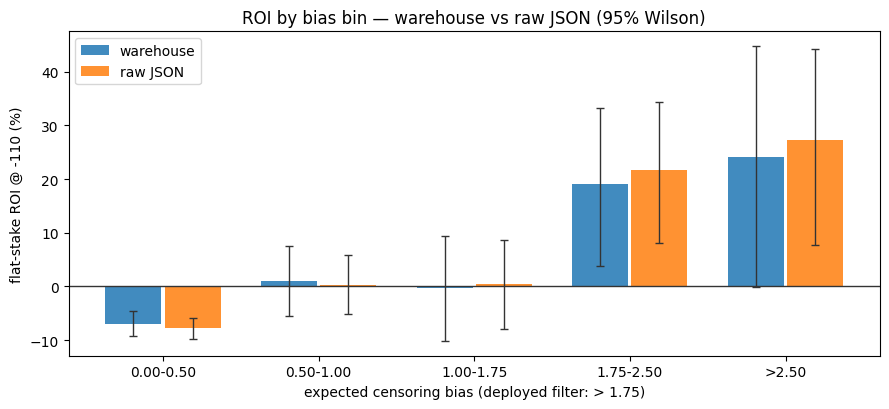

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(len(cmp))
for off, col, lo, hi, lab, c in ((-0.19, "roi_wh", "roi_lo_wh", "roi_hi_wh", "warehouse", "#1f77b4"),
                                 (0.19, "roi_raw", "roi_lo_raw", "roi_hi_raw", "raw JSON", "#ff7f0e")):
    err = np.vstack([cmp[col] - cmp[lo], cmp[hi] - cmp[col]])
    ax.bar(x + off, cmp[col], 0.36, label=lab, color=c, alpha=.85)
    ax.errorbar(x + off, cmp[col], yerr=err, fmt="none", ecolor="#333", lw=1, capsize=3)

ax.axhline(0, color="#333", lw=1)
ax.set_xticks(x); ax.set_xticklabels(cmp.label)
ax.set_xlabel(f"expected censoring bias (deployed filter: > {THRESHOLD})")
ax.set_ylabel("flat-stake ROI @ -110 (%)")
ax.set_title("ROI by bias bin — warehouse vs raw JSON (95% Wilson)")
ax.legend(); fig.tight_layout(); plt.show()

## 6. Three rules, one source question

The 19.92% spread gap is not corruption — both sources agree with their own
`formattedSpread` on every game. It is the selection rule. `pick_line` keeps only
providers carrying **both** a spread and a total, so a consensus spread published
without a consensus total is discarded and the model falls back to whatever book
the JSON listed first, usually a projection site. `core.fact_game` picks each
field independently and keeps the consensus spread.

So run three rules and see what the choice is worth.

In [17]:
from warehouse_source import load_warehouse_seasons as _lw

# Two things changed at once -- the source AND the span -- so separate them.
rw_2017 = {y: v for y, v in rw_data.items() if y >= 2017}

configs = {
    "raw 2013+ (previous)":      rw_data,
    "raw 2017+ (span only)":     rw_2017,
    "wh fact_game 2017+":        wh_data,
    "wh fact_game_line 2017+":   _lw(SEASONS_MODEL, lines="fact_game_line"),   # SHIPPED
}
for label, d in configs.items():
    run(d, label)

raw 2013+ (previous)  N= 275  178-97  hit= 64.73%  ROI= +23.57%  95% [+12.47, +33.90]


raw 2017+ (span only)  N= 211  134-77  hit= 63.51%  ROI= +21.24%  95% [+8.48, +33.08]


wh fact_game 2017+  N= 209  132-77  hit= 63.16%  ROI= +20.57%  95% [+7.74, +32.50]


wh fact_game_line 2017+  N= 210  141-69  hit= 67.14%  ROI= +28.18%  95% [+15.56, +39.63]


In [18]:
PROJECTION = {"numberfire", "teamrankings"}

pair = load_warehouse_frame(SEASONS_MODEL, lines="fact_game_line")
mix = {"raw / pick_line": None, "wh fact_game": wh, "wh fact_game_line": pair}
for label, frame in mix.items():
    if frame is None:
        continue
    sp = frame.spread_provider.str.lower()
    tp = frame.total_provider.str.lower()
    print(f"{label:24} consensus spread {(sp=='consensus').mean():6.1%}   "
          f"projection spread {sp.isin(PROJECTION).mean():6.1%}   "
          f"projection EITHER field {(sp.isin(PROJECTION)|tp.isin(PROJECTION)).mean():6.1%}")

wh fact_game             consensus spread  49.9%   projection spread   0.0%   projection EITHER field   0.0%
wh fact_game_line        consensus spread  49.8%   projection spread   0.0%   projection EITHER field   0.0%


Read the four rows together. `raw 2017+` isolates the span change on its own —
whatever separates it from `raw 2013+` is the four dropped seasons, not the
source. Whatever separates the two warehouse rows from `raw 2017+` is the
source and its line-selection rule.

The shipped row is `wh fact_game_line 2017+`. Its ROI is the highest of the
four, and that is *not* a reason to prefer it: it is the smallest and most
recent sample, and the 1.75 threshold it is being scored against was chosen on
the full raw history. Prefer it because every line in it was quoted by a book,
not because the number is bigger.

Note the last column: both core tables are 0% projection, by construction. The
core build strips `teamrankings` and `numberfire` before selection
(`duckdb_core.py:292`), which is exactly why neither carries a usable total
before 2017 — CFBD published no consensus total until then, so a projection was
the only number available and the builder refuses to present it as a price.

The raw path shows ~23% instead, which is the same fact seen from the other
side: roughly a quarter of the old sample was priced off numbers no book hung.

## 7. What this does and does not show

- **Does show** whether the warehouse reproduces the raw-sourced walk-forward,
  and exactly which games and lines the two sources disagree on.
- **Does not re-grade the committed result.** `docs/ROI_HITRATE.md` stays the
  raw-sourced record. If the warehouse is adopted as the model's source, that is
  a separate change with its own write-up, and
  `docs/model-evaluation-standard.md` binds any ROI claim made from it.
- **No proper score here.** Hit rate, ROI and Wilson intervals only — no Brier
  or log-loss against the de-vigged market, which the evaluation standard asks
  for at Tier 1. That gap is inherited from the existing generators.
- **The threshold was chosen partly on this data**, so the pooled point estimate
  is inflated either way; the lower bound is the planning number.
- **2026 is partial** — weeks 1-3 only, so its row moves every week.

Nothing above wrote to `docs/`.